# Exploring Trial Orbits with `digest2`

#### This tutorial demonstrates how to extract and analyze the individual trial orbits generated during digest2's statistical ranging process.

When `digest2` classifies a tracklet, it internally generates thousands of trial orbits consistent with the observed motion. Each trial orbit has orbital elements (q, e, i, H) that are binned into the population model to produce classification scores. With the `collect_orbits=True` option, you can access these individual trial orbits and explore the full range of orbital solutions consistent with your observations.

This can be useful if you want to:
- Understand *why* a tracklet received a particular classification score
- Visualize the range of orbits consistent with a short-arc observation
- Compare how different observing scenarios (error models, arc lengths) constrain the orbital solution space
- Investigate which regions of (q, e, i, H) space are accessible for a given tracklet

<p style="color:#b30000;"><strong>WARNING:</strong> <code>collect_orbits=True</code> can induce heavy memory use, enabling storage of every collected trial orbit and can consume substantial RAM (often hundreds of MB per tracklet, and in some cases approaching ~1 GB).</p>

<strong>Normal operation guidance:</strong> when you only need digest2 classification scores, keep <code>collect_orbits</code> at the default <code>False</code>. Enable it only when you explicitly need orbit-level diagnostic/analysis data.</p>

**References:**
- Keys et al. 2019, (["The digest2 NEO Classification Code"](https://ui.adsabs.harvard.edu/abs/2019PASP..131f4501K/abstract))
- Veres et al. 2023, (["Improvement of Digest2 NEO Classification Code"](https://ui.adsabs.harvard.edu/abs/2023PASP..135j4505V/abstract))

## Environment Setup

To run this notebook, you need a Python environment (>= 3.9) with `digest2` and its dependencies installed. We recommend creating a dedicated conda environment and registering it as a Jupyter kernel:

```bash
# Create and activate environment
conda create -n digest2-notebook-env python=3.12 -y
conda activate digest2-notebook-env

# Install digest2 and notebook dependencies
pip install digest2 requests numpy matplotlib ipykernel

# Register as a Jupyter kernel
python -m ipykernel install --user --name digest2-notebook-env --display-name "Python (digest2-notebook-env)"
```

Then open this notebook in Jupyter and select **Kernel > Change Kernel > Python (digest2-notebook-env)**.

If you are working from a local clone of the repository and want to install that, replace `pip install digest2` with:

```bash
cd mpc-public/digest2
pip install '.[test]' requests numpy matplotlib ipykernel
```

## Imports

In [ ]:
from digest2 import Digest2, Observation, classify, ClassificationResult, TrialOrbit
from digest2.observation import parse_mpc80_file
import numpy as np
import matplotlib.pyplot as plt
import requests
import tempfile
import os
import atexit

## Setup: Download Sample Data

`digest2` requires an observatory codes file (`digest2.obscodes`) to look up parallax constants for each observatory. We download this from the MPC's [Observatory Codes API](https://docs.minorplanetcenter.net/mpc-ops-docs/apis/obscodes/).

We also create sample observation files for use throughout the tutorial.

In [ ]:
# Create a temporary directory for our working files
tmpdir = tempfile.mkdtemp(prefix="digest2_trial_orbits_")
atexit.register(lambda: __import__('shutil').rmtree(tmpdir, ignore_errors=True))

# Download observatory codes from the MPC obscodes API
response = requests.get(
    "https://data.minorplanetcenter.net/api/obscodes",
    json={"format": "ObsCodes.html"}
)
response.raise_for_status()

obscodes_path = os.path.join(tmpdir, "digest2.obscodes")
with open(obscodes_path, "w") as f:
    f.write(response.text)
print(f"Observatory codes downloaded to: {obscodes_path}")
print(f"  ({len(response.text.splitlines())} lines)")

Observatory codes downloaded to: /var/folders/67/j23cbc8x5r3b_1cy48v0rf4m0000gq/T/digest2_trial_orbits_h4gch27_/digest2.obscodes
  (2681 lines)


In [ ]:
# Sample MPC 80-column observation file: 3 observations of 2016 SK99 from G96 (Mt. Lemmon)
sample_obs_content = """     K16S99K 1C2022 12 25.38496508 32 36.283+17 10 35.94         21.98GV     G96
     K16S99K 1C2022 12 25.39527308 32 35.635+17 10 37.27         21.72GV     G96
     K16S99K 1C2022 12 25.40040208 32 35.473+17 10 37.38         21.31GV     G96
"""

sample_obs_path = os.path.join(tmpdir, "sample.obs")
with open(sample_obs_path, "w") as f:
    f.write(sample_obs_content)

print(f"Sample .obs file: {sample_obs_path}")

Sample .obs file: /var/folders/67/j23cbc8x5r3b_1cy48v0rf4m0000gq/T/digest2_trial_orbits_h4gch27_/sample.obs


## Collecting Trial Orbits: Basic Usage

By default, `digest2` discards the individual trial orbits after scoring. To retain them, pass `collect_orbits=True` to any classification method (`classify_tracklet`, `classify_file`, `classify_batch`, or the `classify` convenience function).

The trial orbits are stored in the `trial_orbits` field of the `ClassificationResult` as a tuple of `TrialOrbit` dataclass objects.

In [ ]:
%%time
# Classify with trial orbit collection enabled
results = classify(
    sample_obs_path,
    obscodes_path=obscodes_path,
    repeatable=True,
    collect_orbits=True,
)

r = results[0]

print(f"Designation: {r.designation}")
print(f"NEO score (noid): {r.noid.NEO:.1f}")
print(f"MB1 score (noid): {r.noid.MB1:.1f}")
print(f"RMS: {r.rms:.2f} arcsec")
print()
print(f"Trial orbits collected: {r.trial_orbits is not None}")
print(f"Number of trial orbits: {len(r.trial_orbits):,}")

CPU times: user 5 μs, sys: 0 ns, total: 5 μs
Wall time: 11 μs
Designation: K16S99K
NEO score (noid): 13.3
MB1 score (noid): 72.3
RMS: 0.73 arcsec

Trial orbits collected: True
Number of trial orbits: 342,569


## The TrialOrbit Dataclass

Each `TrialOrbit` contains the orbital elements and metadata for a single trial orbit:

Please see appendix A in Keys et al. 2019, (["The digest2 NEO Classification Code"](https://ui.adsabs.harvard.edu/abs/2019PASP..131f4501K/abstract)) for a detailed understanding of the angular parameter, `an` used in the orbit solution. 


| Attribute | Type | Description |
|-----------|------|-------------|
| `q` | `float` | Perihelion distance (AU) |
| `e` | `float` | Eccentricity |
| `i` | `float` | Inclination (degrees) |
| `H` | `float` | Absolute magnitude |
| `d` | `float` | Geocentric distance used to generate this orbit (AU) |
| `an` | `float` | Angle parameter used in the orbit solution (radians) |
| `iq` | `int` | q bin index (0..28) |
| `ie` | `int` | e bin index (0..7) |
| `ii` | `int` | i bin index (0..10) |
| `ih` | `int` | H bin index (0..17) |
| `new_tag` | `bool` | True if this orbit tagged a previously unvisited model bin |

Let's inspect a few individual trial orbits.

In [ ]:
# Look at the first few trial orbits
print(f"{'#':>5s}  {'q (AU)':>8s}  {'e':>6s}  {'i (deg)':>8s}  {'H':>6s}  {'d (AU)':>8s}  {'new_tag':>7s}")
print("-" * 60)
for idx in range(5):
    t = r.trial_orbits[idx]
    print(f"{idx:5d}  {t.q:8.3f}  {t.e:6.3f}  {t.i:8.1f}  {t.H:6.1f}  {t.d:8.3f}  {str(t.new_tag):>7s}")

print(f"  ...")

# Also show the last few
for idx in range(len(r.trial_orbits) - 3, len(r.trial_orbits)):
    t = r.trial_orbits[idx]
    print(f"{idx:5d}  {t.q:8.3f}  {t.e:6.3f}  {t.i:8.1f}  {t.H:6.1f}  {t.d:8.3f}  {str(t.new_tag):>7s}")

    #    q (AU)       e   i (deg)       H    d (AU)  new_tag
------------------------------------------------------------
    0     0.207   0.760       2.1    27.0     0.050     True
    1     0.089   0.925       4.4    27.0     0.050     True
    2     0.052   0.970       6.6    27.0     0.050     True
    3     0.039   0.982       8.0    27.0     0.050    False
    4     0.066   0.954       5.6    27.0     0.050    False
  ...
342566     7.346   0.813     164.3    13.1     6.639    False
342567     6.737   0.926     164.1    13.1     6.639    False
342568     7.008   0.870     164.2    13.1     6.639    False


## Converting to NumPy Arrays

For efficient analysis and plotting, the `orbit_elements` property converts the tuple of `TrialOrbit` objects into a dictionary of NumPy arrays.

In [ ]:
elems = r.orbit_elements

print("Available keys:", sorted(elems.keys()))
print()
for key in ["q", "e", "i", "H", "d", "an"]:
    arr = elems[key]
    print(f"  {key:>3s}: shape={arr.shape}, dtype={arr.dtype}, "
          f"range=[{arr.min():.3f}, {arr.max():.3f}], median={np.median(arr):.3f}")

print()
print(f"  new_tag: {elems['new_tag'].sum():,} True out of {len(elems['new_tag']):,} total")

Available keys: ['H', 'an', 'd', 'e', 'i', 'ie', 'ih', 'ii', 'iq', 'new_tag', 'q']

    q: shape=(342569,), dtype=float64, range=[0.022, 7.534], median=1.015
    e: shape=(342569,), dtype=float64, range=[0.004, 0.990], median=0.658
    i: shape=(342569,), dtype=float64, range=[0.076, 178.642], median=3.681
    H: shape=(342569,), dtype=float64, range=[13.030, 27.026], median=17.999
    d: shape=(342569,), dtype=float64, range=[0.050, 6.687], median=1.689
   an: shape=(342569,), dtype=float64, range=[0.062, 3.094], median=1.712

  new_tag: 45,025 True out of 342,569 total


## Visualizing the Orbital Element Distributions

Let's plot the distributions of the four main orbital elements (q, e, i, H) for all trial orbits. These distributions reveal the full range of orbital solutions that are geometrically consistent with the observed tracklet.

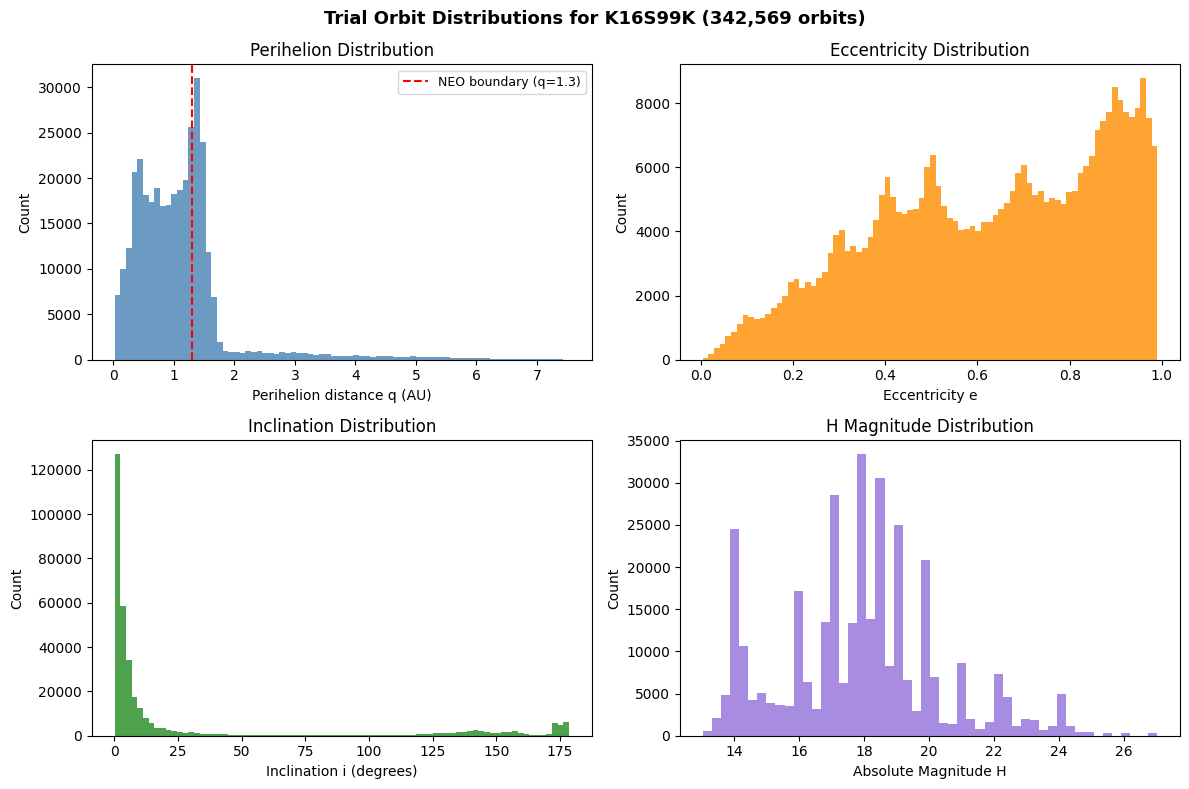

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(elems["q"], bins=80, color="steelblue", edgecolor="none", alpha=0.8)
axes[0, 0].set_xlabel("Perihelion distance q (AU)")
axes[0, 0].set_ylabel("Count")
axes[0, 0].set_title("Perihelion Distribution")
axes[0, 0].axvline(1.3, color="red", linestyle="--", linewidth=1.5, label="NEO boundary (q=1.3)")
axes[0, 0].legend(fontsize=9)

axes[0, 1].hist(elems["e"], bins=80, color="darkorange", edgecolor="none", alpha=0.8)
axes[0, 1].set_xlabel("Eccentricity e")
axes[0, 1].set_ylabel("Count")
axes[0, 1].set_title("Eccentricity Distribution")

axes[1, 0].hist(elems["i"], bins=80, color="forestgreen", edgecolor="none", alpha=0.8)
axes[1, 0].set_xlabel("Inclination i (degrees)")
axes[1, 0].set_ylabel("Count")
axes[1, 0].set_title("Inclination Distribution")

axes[1, 1].hist(elems["H"], bins=50, color="mediumpurple", edgecolor="none", alpha=0.8)
axes[1, 1].set_xlabel("Absolute Magnitude H")
axes[1, 1].set_ylabel("Count")
axes[1, 1].set_title("H Magnitude Distribution")

fig.suptitle(f"Trial Orbit Distributions for {r.designation} ({len(r.trial_orbits):,} orbits)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Orbital Element Correlations

The trial orbits are not independent draws from a uniform distribution. The constraints imposed by the observed sky motion create strong correlations between orbital elements. Let's visualize these using scatter plots.

To keep the plots readable, we subsample if there are many trial orbits.

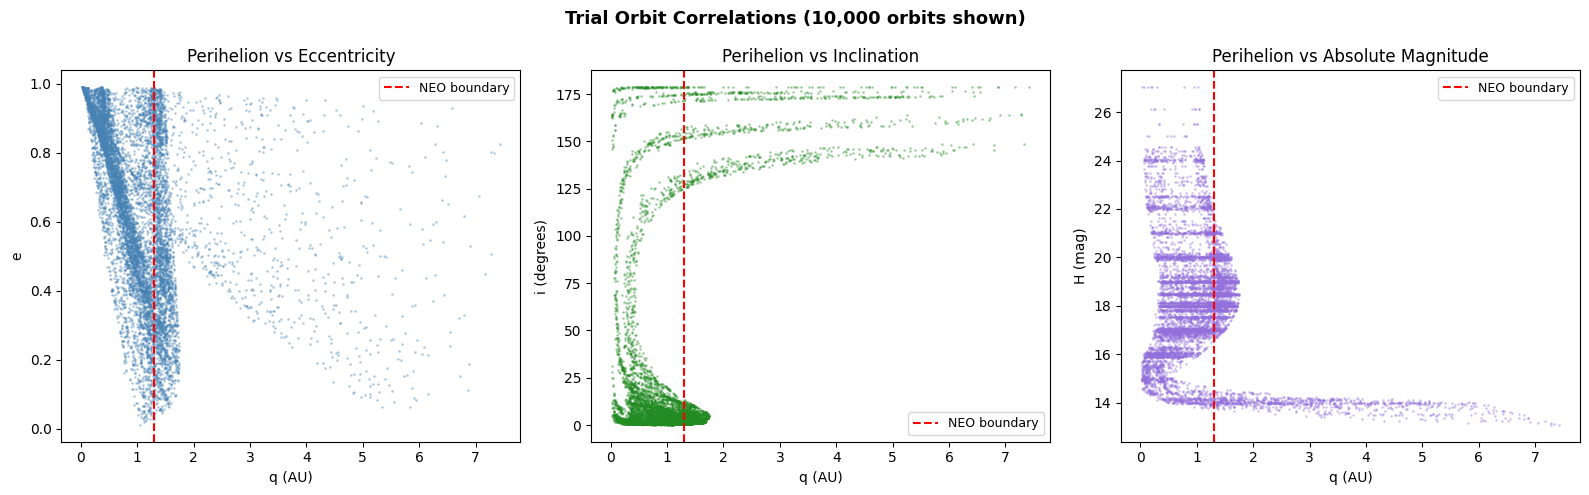

In [ ]:
# Subsample for plotting performance
n_plot = min(10000, len(elems["q"]))
rng = np.random.default_rng(42)
idx = rng.choice(len(elems["q"]), size=n_plot, replace=False)

q_s = elems["q"][idx]
e_s = elems["e"][idx]
i_s = elems["i"][idx]
H_s = elems["H"][idx]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# q vs e
axes[0].scatter(q_s, e_s, s=1, alpha=0.3, c="steelblue")
axes[0].axvline(1.3, color="red", linestyle="--", linewidth=1.5, label="NEO boundary")
axes[0].set_xlabel("q (AU)")
axes[0].set_ylabel("e")
axes[0].set_title("Perihelion vs Eccentricity")
axes[0].legend(fontsize=9)

# q vs i
axes[1].scatter(q_s, i_s, s=1, alpha=0.3, c="forestgreen")
axes[1].axvline(1.3, color="red", linestyle="--", linewidth=1.5, label="NEO boundary")
axes[1].set_xlabel("q (AU)")
axes[1].set_ylabel("i (degrees)")
axes[1].set_title("Perihelion vs Inclination")
axes[1].legend(fontsize=9)

# q vs H
axes[2].scatter(q_s, H_s, s=1, alpha=0.3, c="mediumpurple")
axes[2].axvline(1.3, color="red", linestyle="--", linewidth=1.5, label="NEO boundary")
axes[2].set_xlabel("q (AU)")
axes[2].set_ylabel("H (mag)")
axes[2].set_title("Perihelion vs Absolute Magnitude")
axes[2].legend(fontsize=9)

fig.suptitle(f"Trial Orbit Correlations ({n_plot:,} orbits shown)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Understanding `new_tag`: Bin Discovery

The `new_tag` flag indicates whether a trial orbit was the first to visit a particular (q, e, i, H) bin in the population model. The digest2 algorithm iteratively generates trial orbits until it stops discovering new bins (diminishing returns). Orbits with `new_tag=True` are the ones that expanded the coverage of solution space.

Let's compare the element distributions for "new tag" orbits (those that discovered new bins) vs. "repeat" orbits (those that fell into already-visited bins).

New-tag orbits:   45,025 (13.1%)
Repeat orbits:   297,544 (86.9%)



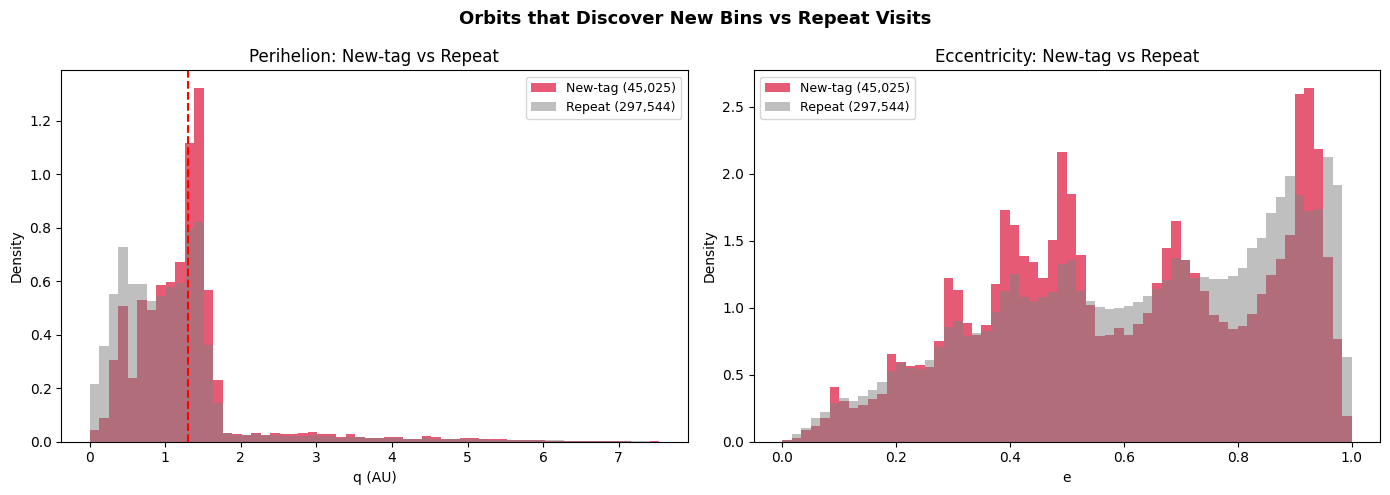

In [ ]:
mask_new = elems["new_tag"]
mask_repeat = ~mask_new

n_new = mask_new.sum()
n_repeat = mask_repeat.sum()
print(f"New-tag orbits:  {n_new:>7,} ({100 * n_new / len(mask_new):.1f}%)")
print(f"Repeat orbits:   {n_repeat:>7,} ({100 * n_repeat / len(mask_new):.1f}%)")
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# q distribution: new vs repeat
q_range = (0, min(elems["q"].max(), 8))
axes[0].hist(elems["q"][mask_new], bins=60, range=q_range, alpha=0.7,
             color="crimson", label=f"New-tag ({n_new:,})", density=True)
axes[0].hist(elems["q"][mask_repeat], bins=60, range=q_range, alpha=0.5,
             color="gray", label=f"Repeat ({n_repeat:,})", density=True)
axes[0].axvline(1.3, color="red", linestyle="--", linewidth=1.5)
axes[0].set_xlabel("q (AU)")
axes[0].set_ylabel("Density")
axes[0].set_title("Perihelion: New-tag vs Repeat")
axes[0].legend(fontsize=9)

# e distribution: new vs repeat
axes[1].hist(elems["e"][mask_new], bins=60, range=(0, 1), alpha=0.7,
             color="crimson", label=f"New-tag ({n_new:,})", density=True)
axes[1].hist(elems["e"][mask_repeat], bins=60, range=(0, 1), alpha=0.5,
             color="gray", label=f"Repeat ({n_repeat:,})", density=True)
axes[1].set_xlabel("e")
axes[1].set_ylabel("Density")
axes[1].set_title("Eccentricity: New-tag vs Repeat")
axes[1].legend(fontsize=9)

fig.suptitle("Orbits that Discover New Bins vs Repeat Visits",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Comparing Trial Orbits for Different Tracklets

One powerful application of trial orbit collection is comparing the orbital solution space for different tracklets. Let's create two contrasting cases: one that scores as a likely Main Belt object, and one that scores as a likely NEO.

In [ ]:
# Tracklet A: slow-moving, faint -- likely Main Belt
tracklet_a = [
    Observation(mjd=59938.384965, ra=128.15118, dec=17.17665,
                mag=22.22, band="G", obscode="G96"),
    Observation(mjd=59938.406273, ra=128.14899, dec=17.17702,
                mag=21.96, band="G", obscode="G96"),
    Observation(mjd=59938.416402, ra=128.14780, dec=17.17717,
                mag=21.55, band="G", obscode="G96"),
]

# Tracklet B: faster-moving -- more likely NEO
tracklet_b = [
    Observation(mjd=59938.384965, ra=130.0, dec=20.0,
                mag=20.0, obscode="G96"),
    Observation(mjd=59938.395273, ra=130.01, dec=20.01,
                mag=20.0, obscode="G96"),
]

with Digest2(obscodes_path=obscodes_path, repeatable=True) as d2:
    result_a = d2.classify_tracklet(tracklet_a, collect_orbits=True)
    result_b = d2.classify_tracklet(tracklet_b, collect_orbits=True)

print("Tracklet A (slow-moving):")
print(f"  NEO={result_a.noid.NEO:.1f}, MB1={result_a.noid.MB1:.1f}, "
      f"trial orbits: {len(result_a.trial_orbits):,}")

print("\nTracklet B (faster-moving):")
print(f"  NEO={result_b.noid.NEO:.1f}, MB1={result_b.noid.MB1:.1f}, "
      f"trial orbits: {len(result_b.trial_orbits):,}")

Tracklet A (slow-moving):
  NEO=2.5, MB1=41.2, trial orbits: 382,878

Tracklet B (faster-moving):
  NEO=100.0, MB1=0.0, trial orbits: 43,640


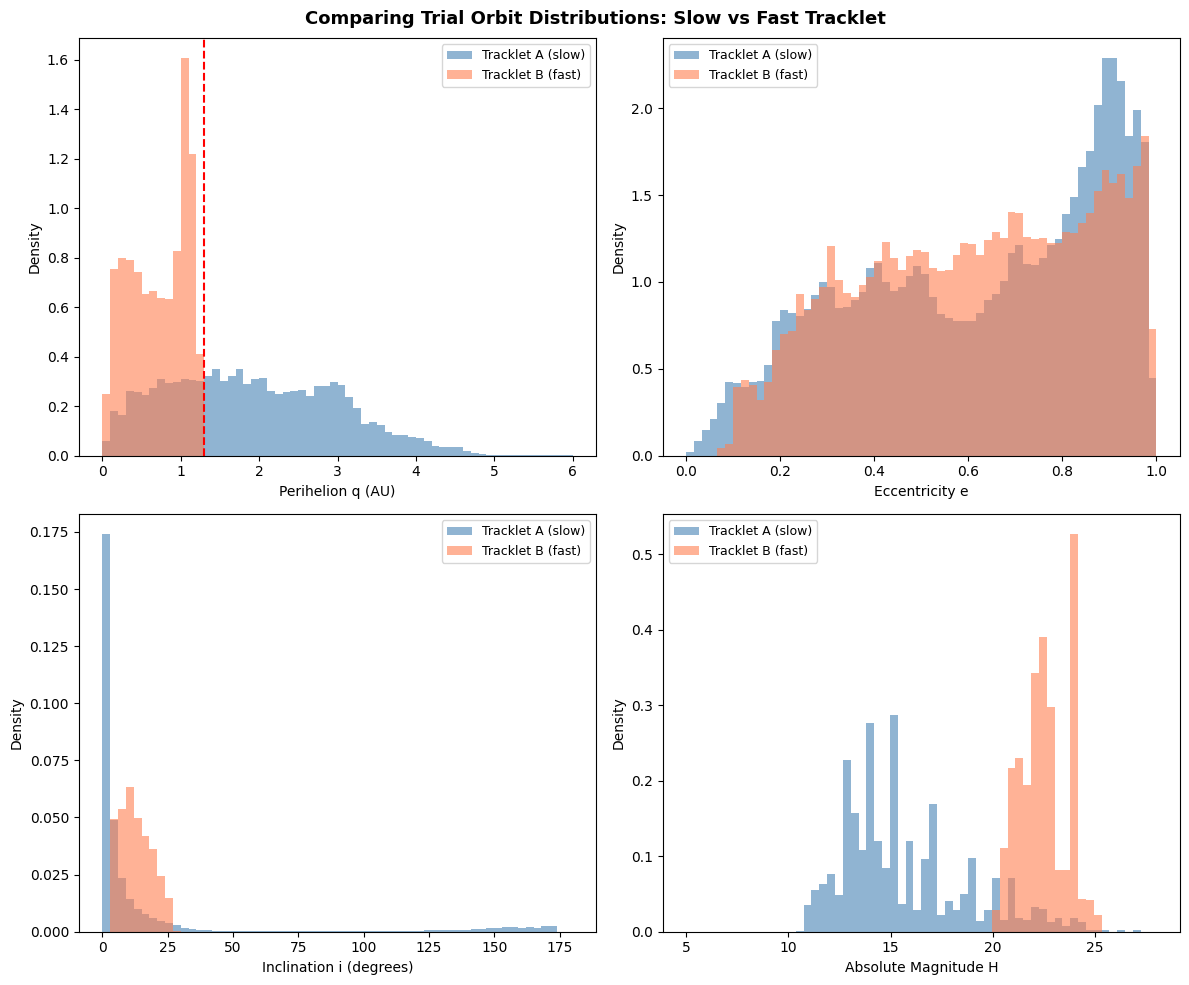

In [ ]:
elems_a = result_a.orbit_elements
elems_b = result_b.orbit_elements

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for col, (key, label, xlim) in enumerate([
    ("q", "Perihelion q (AU)", (0, 6)),
    ("e", "Eccentricity e", (0, 1)),
]):
    axes[0, col].hist(elems_a[key], bins=60, range=xlim, alpha=0.6,
                      color="steelblue", label="Tracklet A (slow)", density=True)
    axes[0, col].hist(elems_b[key], bins=60, range=xlim, alpha=0.6,
                      color="coral", label="Tracklet B (fast)", density=True)
    if key == "q":
        axes[0, col].axvline(1.3, color="red", linestyle="--", linewidth=1.5)
    axes[0, col].set_xlabel(label)
    axes[0, col].set_ylabel("Density")
    axes[0, col].legend(fontsize=9)

for col, (key, label, xlim) in enumerate([
    ("i", "Inclination i (degrees)", (0, 180)),
    ("H", "Absolute Magnitude H", (5, 28)),
]):
    axes[1, col].hist(elems_a[key], bins=60, range=xlim, alpha=0.6,
                      color="steelblue", label="Tracklet A (slow)", density=True)
    axes[1, col].hist(elems_b[key], bins=60, range=xlim, alpha=0.6,
                      color="coral", label="Tracklet B (fast)", density=True)
    axes[1, col].set_xlabel(label)
    axes[1, col].set_ylabel("Density")
    axes[1, col].legend(fontsize=9)

fig.suptitle("Comparing Trial Orbit Distributions: Slow vs Fast Tracklet",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Effect of Observational Errors on Trial Orbits

The assumed astrometric error affects how tightly the trial orbits are constrained. Smaller errors mean the observed sky position is more precise, restricting the range of compatible orbits. Let's compare the trial orbit distributions for tight vs. loose observatory errors.

In [ ]:
# Config with tight errors
tight_config = os.path.join(tmpdir, "tight.cfg")
with open(tight_config, "w") as f:
    f.write("obserrG96=0.15\n")

# Config with loose errors
loose_config = os.path.join(tmpdir, "loose.cfg")
with open(loose_config, "w") as f:
    f.write("obserrG96=2.0\n")

obs_for_err_test = [
    Observation(mjd=59938.384965, ra=128.15118, dec=17.17665,
                mag=22.22, band="G", obscode="G96"),
    Observation(mjd=59938.395273, ra=128.14899, dec=17.17702,
                mag=21.96, band="G", obscode="G96"),
    Observation(mjd=59938.400402, ra=128.14780, dec=17.17717,
                mag=21.55, band="G", obscode="G96"),
]

with Digest2(config_path=tight_config, obscodes_path=obscodes_path, repeatable=True) as d2:
    r_tight = d2.classify_tracklet(obs_for_err_test, collect_orbits=True)

with Digest2(config_path=loose_config, obscodes_path=obscodes_path, repeatable=True) as d2:
    r_loose = d2.classify_tracklet(obs_for_err_test, collect_orbits=True)

print(f'Tight errors (0.15"): NEO={r_tight.noid.NEO:.1f}, MB1={r_tight.noid.MB1:.1f}, '
      f'trial orbits: {len(r_tight.trial_orbits):,}')
print(f'Loose errors (2.0"):  NEO={r_loose.noid.NEO:.1f}, MB1={r_loose.noid.MB1:.1f}, '
      f'trial orbits: {len(r_loose.trial_orbits):,}')

Tight errors (0.15"): NEO=96.8, MB1=0.0, trial orbits: 158,702
Loose errors (2.0"):  NEO=0.5, MB1=65.3, trial orbits: 690,120


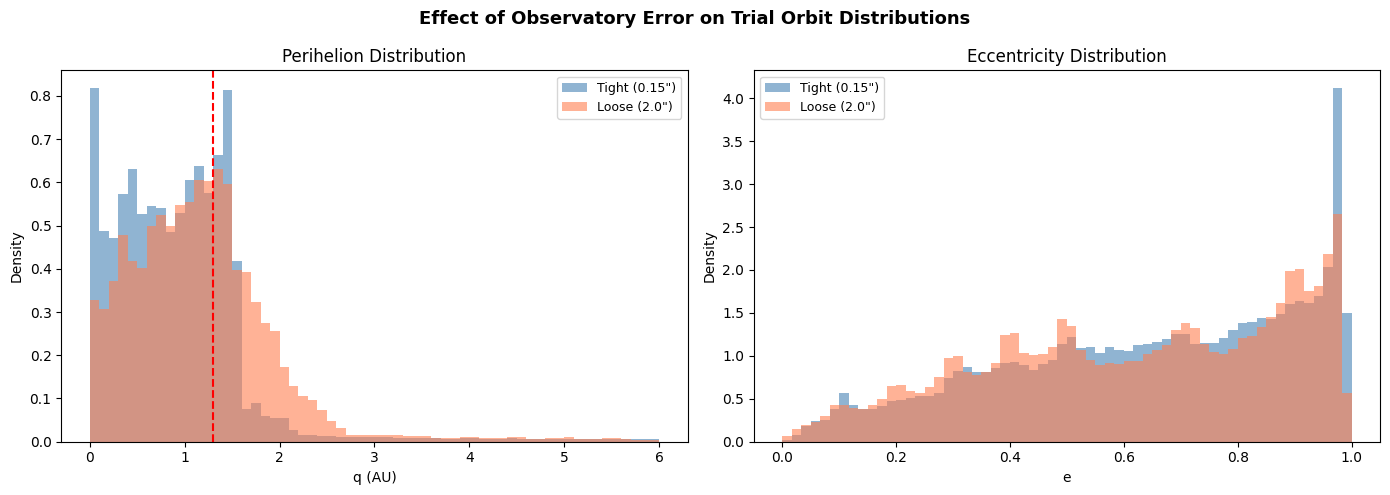

In [ ]:
elems_tight = r_tight.orbit_elements
elems_loose = r_loose.orbit_elements

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# q distributions
q_range = (0, 6)
axes[0].hist(elems_tight["q"], bins=60, range=q_range, alpha=0.6,
             color="steelblue", label='Tight (0.15")', density=True)
axes[0].hist(elems_loose["q"], bins=60, range=q_range, alpha=0.6,
             color="coral", label='Loose (2.0")', density=True)
axes[0].axvline(1.3, color="red", linestyle="--", linewidth=1.5)
axes[0].set_xlabel("q (AU)")
axes[0].set_ylabel("Density")
axes[0].set_title("Perihelion Distribution")
axes[0].legend(fontsize=9)

# e distributions
axes[1].hist(elems_tight["e"], bins=60, range=(0, 1), alpha=0.6,
             color="steelblue", label='Tight (0.15")', density=True)
axes[1].hist(elems_loose["e"], bins=60, range=(0, 1), alpha=0.6,
             color="coral", label='Loose (2.0")', density=True)
axes[1].set_xlabel("e")
axes[1].set_ylabel("Density")
axes[1].set_title("Eccentricity Distribution")
axes[1].legend(fontsize=9)

fig.suptitle("Effect of Observatory Error on Trial Orbit Distributions",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Geocentric Distance and Angle Parameter

The trial orbits are generated by sampling two parameters: the geocentric distance `d` and an angle `an`. These define the orbit solution for a given tracklet. 

Please see appendix A in Keys et al. 2019, (["The digest2 NEO Classification Code"](https://ui.adsabs.harvard.edu/abs/2019PASP..131f4501K/abstract)) for a detailed discussion of the angular parameter, `an` used in the orbit solution. 


Let's examine the distribution of these parameters and how they relate to the resulting orbital elements.

/var/folders/67/j23cbc8x5r3b_1cy48v0rf4m0000gq/T/ipykernel_81695/3778232324.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1,1].legend(fontsize=9)


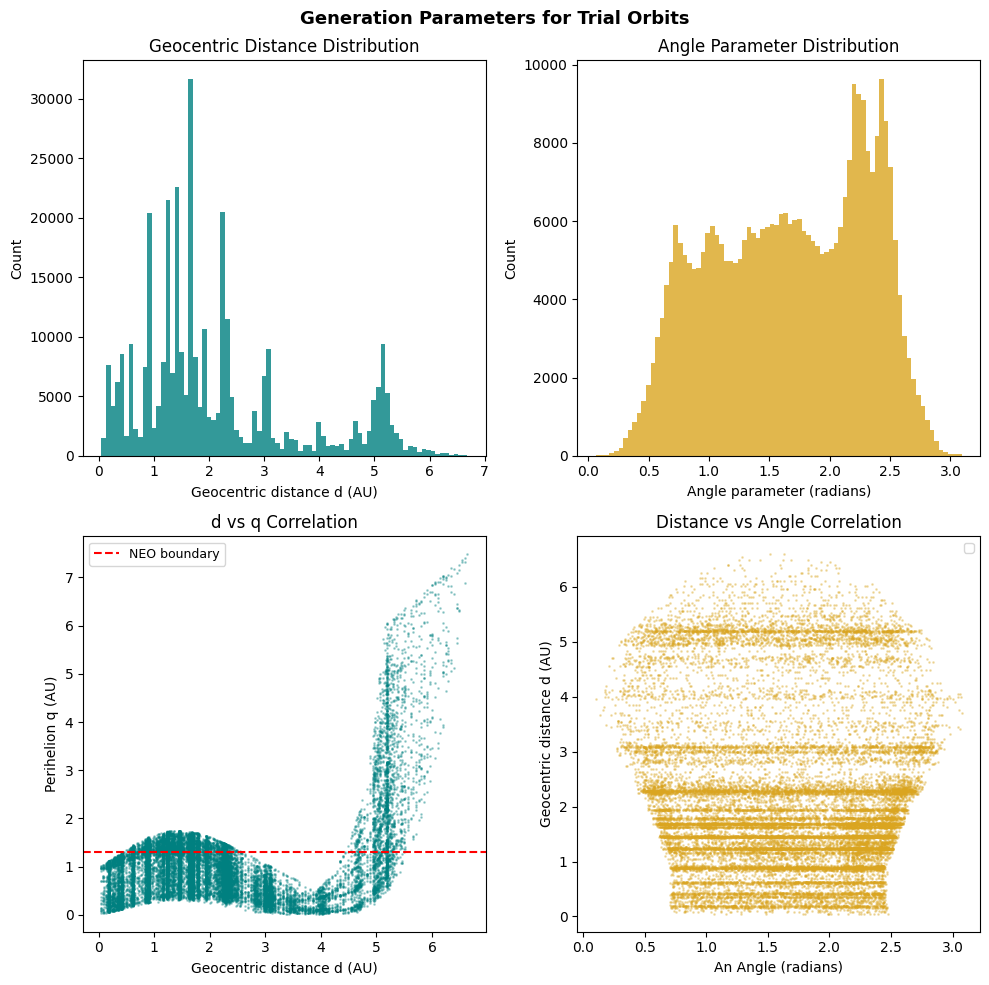

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# d distribution
axes[0,0].hist(elems["d"], bins=80, color="teal", edgecolor="none", alpha=0.8)
axes[0,0].set_xlabel("Geocentric distance d (AU)")
axes[0,0].set_ylabel("Count")
axes[0,0].set_title("Geocentric Distance Distribution")

# an (angle) distribution
axes[0,1].hist(elems["an"], bins=80, color="goldenrod", edgecolor="none", alpha=0.8)
axes[0,1].set_xlabel("Angle parameter (radians)")
axes[0,1].set_ylabel("Count")
axes[0,1].set_title("Angle Parameter Distribution")

# d vs q scatter (subsampled)
n_sub = min(25000, len(elems["d"]))
idx_sub = rng.choice(len(elems["d"]), size=n_sub, replace=False)
axes[1,0].scatter(elems["d"][idx_sub], elems["q"][idx_sub], s=1, alpha=0.3, c="teal")
axes[1,0].set_xlabel("Geocentric distance d (AU)")
axes[1,0].set_ylabel("Perihelion q (AU)")
axes[1,0].set_title("d vs q Correlation")
axes[1,0].axhline(1.3, color="red", linestyle="--", linewidth=1.5, label="NEO boundary")
axes[1,0].legend(fontsize=9)

# d vs Angle scatter (subsampled)
n_sub = min(25000, len(elems["d"]))
idx_sub = rng.choice(len(elems["d"]), size=n_sub, replace=False)
axes[1,1].scatter(elems["an"][idx_sub], elems["d"][idx_sub], s=1, alpha=0.3, c="goldenrod")
axes[1,1].set_xlabel("An Angle (radians)")
axes[1,1].set_ylabel("Geocentric distance d (AU)")
axes[1,1].set_title("Distance vs Angle Correlation")
#axes[1,1].axhline(1.3, color="red", linestyle="--", linewidth=1.5, label="NEO boundary")

fig.suptitle("Generation Parameters for Trial Orbits",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Bin Occupancy Analysis

The population model is binned along 4 dimensions: q (29 bins), e (8 bins), i (11 bins), H (18 bins). Each trial orbit is assigned to a bin, and the `iq`, `ie`, `ii`, `ih` indices tell us which bin. Let's visualize which bins are most frequently visited.

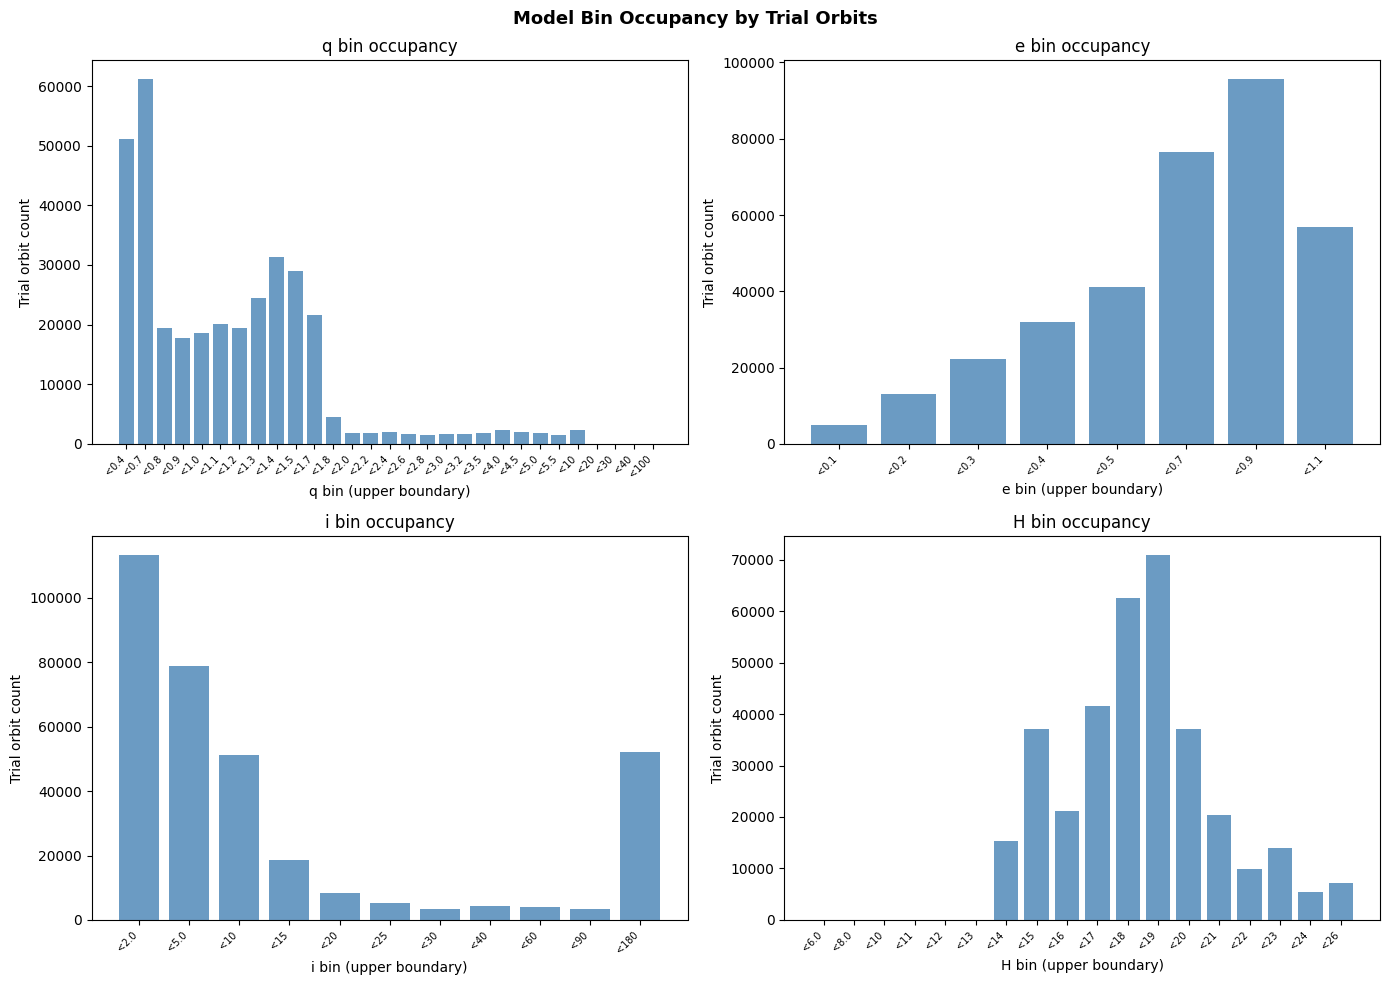

Unique 4D bins visited: 1,082 out of 45,936 possible (2.4%)


In [ ]:
from digest2.population import QPART, EPART, IPART, HPART, QX, EX, IX, HX

# Count orbits per bin index for each dimension
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, key, part, label, nx in [
    (axes[0, 0], "iq", QPART, "q bin", QX),
    (axes[0, 1], "ie", EPART, "e bin", EX),
    (axes[1, 0], "ii", IPART, "i bin", IX),
    (axes[1, 1], "ih", HPART, "H bin", HX),
]:
    counts = np.bincount(elems[key], minlength=nx)
    bin_labels = [f"<{p:.1f}" if p < 10 else f"<{p:.0f}" for p in part]
    bars = ax.bar(range(nx), counts[:nx], color="steelblue", alpha=0.8)
    ax.set_xticks(range(nx))
    ax.set_xticklabels(bin_labels, rotation=45, fontsize=7, ha="right")
    ax.set_xlabel(f"{label} (upper boundary)")
    ax.set_ylabel("Trial orbit count")
    ax.set_title(f"{label} occupancy")

fig.suptitle("Model Bin Occupancy by Trial Orbits",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Count unique bins visited
unique_bins = set(zip(elems["iq"], elems["ie"], elems["ii"], elems["ih"]))
total_possible = QX * EX * IX * HX
print(f"Unique 4D bins visited: {len(unique_bins):,} out of {total_possible:,} possible "
      f"({100 * len(unique_bins) / total_possible:.1f}%)")

## Collecting Trial Orbits from Files

The `collect_orbits` flag also works with `classify_file` and the `classify` convenience function when given a file path. This is useful for batch analysis.

In [ ]:
# Create a multi-tracklet observation file
multi_obs = """     K16S99K 1C2022 12 25.38496508 32 36.283+17 10 35.94         21.98GV     G96
     K16S99K 1C2022 12 25.39527308 32 35.635+17 10 37.27         21.72GV     G96
     K16S99K 1C2022 12 25.40040208 32 35.473+17 10 37.38         21.31GV     G96
     K17R88L 1C2023 11 24.28496518 31 46.283+26 20 35.94         20.38GV     G96
     K17R88L 1C2023 11 24.29527318 31 45.635+26 20 37.27         20.52GV     G96
     K17R88L 1C2023 11 24.30040218 31 45.473+26 20 37.38         20.71GV     G96
"""

multi_path = os.path.join(tmpdir, "multiple.obs")
with open(multi_path, "w") as f:
    f.write(multi_obs)

with Digest2(obscodes_path=obscodes_path, repeatable=True) as d2:
    multi_results = d2.classify_file(multi_path, collect_orbits=True)

for res in multi_results:
    elems_r = res.orbit_elements
    q_med = np.median(elems_r["q"])
    e_med = np.median(elems_r["e"])
    print(f"{res.designation}:  NEO={res.noid.NEO:5.1f}, MB1={res.noid.MB1:5.1f}  "
          f"| {len(res.trial_orbits):,} orbits  "
          f"| median q={q_med:.2f}, median e={e_med:.2f}")

K16S99K:  NEO= 13.3, MB1= 72.3  | 342,569 orbits  | median q=1.01, median e=0.66
K17R88L:  NEO=100.0, MB1=  0.0  | 77,778 orbits  | median q=0.73, median e=0.40


## Default Behavior (Without collect_orbits)

When `collect_orbits` is not set (or set to `False`), the `trial_orbits` field is `None`. This is the default, memory-efficient behavior suitable for bulk classification.

In [ ]:
with Digest2(obscodes_path=obscodes_path, repeatable=True) as d2:
    result_no_orbits = d2.classify_file(multi_path)  # collect_orbits defaults to False

print(f"Scores are the same either way:")
for res in result_no_orbits:
    print(f"trial_orbits: {res.trial_orbits}")
    print(f"orbit_elements: {res.orbit_elements}")
    print(f"  NEO={res.noid.NEO:.1f}, MB1={res.noid.MB1:.1f}")
    print()

    

Scores are the same either way:
trial_orbits: None
orbit_elements: None
  NEO=13.3, MB1=72.3

trial_orbits: None
orbit_elements: None
  NEO=100.0, MB1=0.0



## Relating Trial Orbits to Scores

The digest2 score for each class reflects the fraction of the populated model bins that belong to that class. 

Let's iterate through the trial orbits that were generated with NEO-like elements (q < 1.3 AU) from the `Collecting Trial Orbits from Files`, cell above

Let's use the functionality demonstrated in [mpc_tutorial_digest2_population_model.ipynb](mpc_tutorial_digest2_population_model.ipynb) to,
 - Assign each orbit to a bin
 - Extract the population for each bin.

We can then explicitly calculate the NEO digest2 score, and demonstrate that it is the same as the NEO score explicitly returned by digest2.


In [ ]:
from digest2.population import (
    # Constants
    QPART, EPART, IPART, HPART,
    QX, EX, IX, HX, D2CLASSES,
    CLASS_ABBR, CLASS_HEADING, CLASS_TESTS,
    # Binning
    qeih_to_bin, h_to_bin,
    # Class tests
    is_neo, is_of_mpc_interest, is_inner_mb, is_jfc,
    # I/O
    read_s3m, read_model_csv, write_model_csv,
    read_astorb, build_model,
)

In [ ]:
from pathlib import Path
model_csv_path = Path("../population/digest2.model.csv")
model = read_model_csv(str(model_csv_path))


In [ ]:
"""
Reconstruct the digest2 raw and noid scores from trial orbits + population model.

The scoring algorithm works as follows:
 1. Each trial orbit has raw (q, e, i, H) values and bin indices (iq, ie, ii, ih).
 2. For a given class (e.g. NEO), each orbit is tested against the class
    definition using its raw q, e, i, H values (not the bin boundaries).
 3. Each unique bin is classified as "in-class" if any orbit landing in it
    passed the class test, and "out-of-class" if any orbit failed it.
    A single bin can be BOTH (different orbits in the same bin can straddle
    the class boundary).
 4. For each unique in-class bin, the model population for that class in
    that bin is added to sumAllInClass.
 5. For each unique out-of-class bin, the model population NOT in that class
    is added to sumAllOutOfClass.
 6. rawScore = 100 * sumAllInClass / (sumAllInClass + sumAllOutOfClass)
 7. noIdScore uses unk_class/unk_ss instead of all_class/all_ss.
"""

# --- Use the first tracklet result from "Collecting Trial Orbits from Files" ---
res = multi_results[0]  # K16S99K
trial_orbits = res.trial_orbits
elems = res.orbit_elements

print(f"Tracklet: {res.designation}")
print(f"Trial orbits: {len(trial_orbits):,}")
print(f"Returned raw NEO score:  {res.raw.NEO:.6f}")
print(f"Returned noid NEO score: {res.noid.NEO:.6f}")
print()

# NEO class index in the model arrays
NEO_IDX = CLASS_ABBR.index("NEO")  # = 1

# --- Step 1: Find unique bins and classify each as in-class / out-of-class ---
# A bin is "in-class" for NEO if ANY orbit landing there has q < 1.3
# A bin is "out-of-class" if ANY orbit landing there has q >= 1.3

in_class_bins = set()   # bins where at least one orbit is NEO
out_class_bins = set()  # bins where at least one orbit is NOT NEO

for orb in trial_orbits:
    bin_key = (orb.iq, orb.ie, orb.ii, orb.ih)
    if is_neo(orb.q, orb.e, orb.i, orb.H):
        in_class_bins.add(bin_key)
    else:
        out_class_bins.add(bin_key)

print(f"Unique bins with in-class (NEO) orbits:    {len(in_class_bins):,}")
print(f"Unique bins with out-of-class orbits:      {len(out_class_bins):,}")
print(f"Bins that are both in-class AND out-class:  {len(in_class_bins & out_class_bins):,}")
print()

# --- Step 2: Accumulate population model weights ---
sumAllInClass = 0.0
sumAllOutOfClass = 0.0
sumUnkInClass = 0.0
sumUnkOutOfClass = 0.0

for (iq, ie, ii, ih) in in_class_bins:
    sumAllInClass += model["all_class"][NEO_IDX, iq, ie, ii, ih]
    sumUnkInClass += model["unk_class"][NEO_IDX, iq, ie, ii, ih]

for (iq, ie, ii, ih) in out_class_bins:
    # Out-of-class population = total SS population minus this class's population
    sumAllOutOfClass += (model["all_ss"][iq, ie, ii, ih]
                         - model["all_class"][NEO_IDX, iq, ie, ii, ih])
    sumUnkOutOfClass += (model["unk_ss"][iq, ie, ii, ih]
                         - model["unk_class"][NEO_IDX, iq, ie, ii, ih])

# --- Step 3: Compute scores ---
rawScore = 100.0 * sumAllInClass / (sumAllInClass + sumAllOutOfClass)
noIdScore = 100.0 * sumUnkInClass / (sumUnkInClass + sumUnkOutOfClass)

print(f"Reconstructed raw NEO score:  {rawScore:.6f}")
print(f"Returned raw NEO score:       {res.raw.NEO:.6f}")
print(f"Match: {abs(rawScore - res.raw.NEO) < 1e-6}")
print()
print(f"Reconstructed noid NEO score: {noIdScore:.6f}")
print(f"Returned noid NEO score:      {res.noid.NEO:.6f}")
print(f"Match: {abs(noIdScore - res.noid.NEO) < 1e-6}")


Tracklet: K16S99K
Trial orbits: 342,569
Returned raw NEO score:  9.219613
Returned noid NEO score: 13.282636

Unique bins with in-class (NEO) orbits:    692
Unique bins with out-of-class orbits:      390
Bins that are both in-class AND out-class:  0

Reconstructed raw NEO score:  9.219613
Returned raw NEO score:       9.219613
Match: True

Reconstructed noid NEO score: 13.282636
Returned noid NEO score:      13.282636
Match: True


In [ ]:
"""
Verify the reconstruction works for ALL 15 orbit classes, not just NEO.
"""

print(f"{'Class':>5s}  {'raw(returned)':>14s}  {'raw(recon)':>14s}  {'noid(returned)':>14s}  {'noid(recon)':>14s}  {'match':>5s}")
print("-" * 80)

all_match = True

for c_idx, (abbr, class_test) in enumerate(zip(CLASS_ABBR, CLASS_TESTS)):
    # Classify each orbit as in-class or out-of-class for this class
    in_bins = set()
    out_bins = set()
    for orb in trial_orbits:
        bk = (orb.iq, orb.ie, orb.ii, orb.ih)
        if class_test(orb.q, orb.e, orb.i, orb.H):
            in_bins.add(bk)
        else:
            out_bins.add(bk)

    # Accumulate population weights
    s_all_in = sum(model["all_class"][c_idx, iq, ie, ii, ih] for iq, ie, ii, ih in in_bins)
    s_all_out = sum(model["all_ss"][iq, ie, ii, ih] - model["all_class"][c_idx, iq, ie, ii, ih]
                    for iq, ie, ii, ih in out_bins)
    s_unk_in = sum(model["unk_class"][c_idx, iq, ie, ii, ih] for iq, ie, ii, ih in in_bins)
    s_unk_out = sum(model["unk_ss"][iq, ie, ii, ih] - model["unk_class"][c_idx, iq, ie, ii, ih]
                    for iq, ie, ii, ih in out_bins)

    # Compute scores (matching the C code's fallback for d==0)
    d_raw = s_all_in + s_all_out
    raw_recon = 100.0 * s_all_in / d_raw if d_raw > 0 else (100.0 if c_idx < 2 else 0.0)
    d_noid = s_unk_in + s_unk_out
    noid_recon = 100.0 * s_unk_in / d_noid if d_noid > 0 else (100.0 if c_idx < 2 else 0.0)

    raw_ret = res.raw[abbr]
    noid_ret = res.noid[abbr]
    ok = abs(raw_recon - raw_ret) < 1e-6 and abs(noid_recon - noid_ret) < 1e-6
    all_match = all_match and ok

    print(f"{abbr:>5s}  {raw_ret:14.6f}  {raw_recon:14.6f}  {noid_ret:14.6f}  {noid_recon:14.6f}  {'OK' if ok else 'FAIL':>5s}")

print("-" * 80)
print(f"All 15 classes match: {all_match}")


Class   raw(returned)      raw(recon)  noid(returned)     noid(recon)  match
--------------------------------------------------------------------------------
  Int        9.486220        9.486220       13.533012       13.533012     OK
  NEO        9.219613        9.219613       13.282636       13.282636     OK
  N22        3.288141        3.288141        6.235246        6.235246     OK
  N18        0.868338        0.868338        0.895864        0.895864     OK
   MC       17.302209       17.302209       13.334780       13.334780     OK
  Hun        0.000000        0.000000        0.000000        0.000000     OK
  Pho        0.000000        0.000000        0.000000        0.000000     OK
  MB1       66.122120       66.122120       72.255852       72.255852     OK
  Pal        0.000000        0.000000        0.000000        0.000000     OK
  Han        0.000000        0.000000        0.000000        0.000000     OK
  MB2        6.660588        6.660588        0.314760        0.314760   

## Summary

The `collect_orbits=True` flag gives access to the individual trial orbits generated by digest2's statistical ranging algorithm. This tutorial demonstrated:

| Feature | Description |
|---------|-------------|
| `collect_orbits=True` | Pass to `classify_tracklet`, `classify_file`, `classify_batch`, or `classify` |
| `result.trial_orbits` | Tuple of `TrialOrbit` dataclass objects (q, e, i, H, d, an, bin indices, new_tag) |
| `result.orbit_elements` | Property that converts trial orbits to a dict of NumPy arrays |
| Element distributions | Visualize the range of orbits consistent with the tracklet |
| `new_tag` analysis | Identify orbits that discovered new model bins |
| Tracklet comparison | Compare orbital solution spaces for different tracklets |
| Error effects | See how assumed astrometric errors constrain the solution space |
| Bin occupancy | Inspect which model bins are visited by the trial orbits |

Key considerations:
- Trial orbit collection increases memory usage (often >100k orbits per tracklet)
- Leave `collect_orbits=False` (default) for bulk classification tasks
- Use `collect_orbits=True` for diagnostic and analysis workflows
- The `orbit_elements` property provides NumPy arrays for efficient computation

For more information:
- [digest2 documentation on GitHub](https://github.com/Smithsonian/mpc-public/tree/main/digest2)
- [Keys et al. 2019](https://arxiv.org/abs/1904.09188) -- Algorithm description

For questions or feedback, contact the MPC via the [Jira Helpdesk](https://mpc-service.atlassian.net/servicedesk/customer/portal/13/create/148).